<a href="https://colab.research.google.com/github/juandavidarcila/Metodos-Computacionales/blob/main/Semana8/sistemaslineales_jacobi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

In [ ]:
A = np.array([[3,-1,-1],[-1.,3.,1.],[2,1,4]])
b = np.array([1.,3.,7.])
A

array([[ 3., -1., -1.],
       [-1.,  3.,  1.],
       [ 2.,  1.,  4.]])

In [ ]:
np.linalg.solve(A,b)

array([1., 1., 1.])

In [ ]:
xsol = np.linalg.solve(A,b)
xsol

array([1., 1., 1.])

In [ ]:
def GetZ(A,b,x,y,i):
    return (b[i] - A[i,0]*x - A[i,1]*y)/A[i,2]

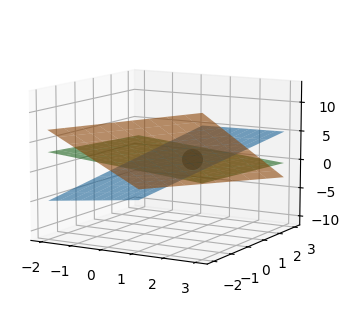

In [ ]:
x = np.linspace(-2,3,10)
y = np.linspace(-2,3,10)
X,Y = np.meshgrid(x,y)

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d', elev=10, azim = -60)

for i in range(3):
    ax.plot_surface(X,Y,GetZ(A,b,X,Y,i),alpha=0.6)

ax.scatter(xsol[0],xsol[1],xsol[2],color='k',s=200)

In [ ]:
import plotly.graph_objects as go

surfaces = []
for i in range(3):
    Z = GetZ(A, b, X, Y, i)
    surfaces.append(
        go.Surface(
            x=X, y=Y, z=Z,
            opacity=0.4,
            colorscale='Viridis',
            showscale=False,
            name=f"Plano {i+1}"
        )
    )

fig = go.Figure(data=surfaces)

point = go.Scatter3d(
    x=[xsol[0]], y=[xsol[1]], z=[xsol[2]],
    mode='markers+text',
    text=[f"sol: ({xsol[0]:.3f}, {xsol[1]:.3f}, {xsol[2]:.3f})"],
    textposition="top center",
    marker=dict(size=3),
    name="Solución"
)

fig.add_trace(point)
fig.show()

In [ ]:
def Jacobi(A,b,x0,itmax = 1000, tolerancia = 1e-16):

  # X0 es la semilla
  x = x0.copy()

  for it in range(itmax):

    x_new = np.copy(x)

    # Itereo sobre las fila
    for i in range(A.shape[0]):

      Suma = 0.
      for j in range(A.shape[1]):
        if j != i:
          Suma += A[i,j]*x[j]

      x_new[i] = (b[i] - Suma)/A[i,i]

      x[i] = x_new[i]

    # Calculo la norma del residuo
    #print(x,it)

    residuo = np.linalg.norm( np.dot(A,x) - b )
    #print(residuo)

    if np.linalg.norm( np.dot(A,x) - b ) < tolerancia:
      print(x,it)
      break

  return x

In [ ]:
x0 = np.array([1.,2.,3.])
Jacobi(A,b,x0)

[1. 1. 1.] 26


array([1., 1., 1.])

In [ ]:
import numpy as np

A = np.array([[4, -1, 1, 1],[1, 5, -1, 1],[2, -1, 6, -1],[1, 1, -1, 7]], dtype=float)
b = np.array([7, -8, 9, 12], dtype=float)

D_inv = np.array([[4, 0, 0, 0],[0, 5, 0, 0],[0, 0, 6, 0],[0, 0, 0, 7]], dtype=float)
R = np.array([[0, -1, 1, 1],[1, 0, -1, 1],[2, -1, 0, -1],[1, 1, -1, 0]], dtype=float)

x = np.zeros(4, dtype=float)

N = 100

for k in range(N):
  x_new = np.zeros(4, dtype=float)

  x_new[0] = (7 + x[1] - x[2] - x[3]) / 4
  x_new[1] = (-8 - x[0] + x[2] - x[3]) / 5
  x_new[2] = (9 - 2*x[0] + x[1] + x[3]) / 6
  x_new[3] = (12 - x[0] - x[1] + x[2]) / 7

  x = x_new

print("Solucion aproximada:")
print(x)

Solucion aproximada:
[ 0.41176471 -1.82352941  1.41176471  2.11764706]


In [ ]:
import numpy as np

A = np.array([[4, -1, 1, 1],
              [1, 5, -1, 1],
              [2, -1, 6, -1],
              [1, 1, -1, 7]], dtype=float)

b = np.array([7, -8, 9, 12], dtype=float)

x = np.zeros(4, dtype=float)

N = 50

for k in range(N):
    x_new = np.zeros(4, dtype=float)

    x_new[0] = (7 + x[1] - x[2] - x[3]) / 4
    x_new[1] = (-8 - x[0] + x[2] - x[3]) / 5
    x_new[2] = (9 - 2*x[0] + x[1] + x[3]) / 6
    x_new[3] = (12 - x[0] - x[1] + x[2]) / 7

    x = x_new

print("Solución aproximada:")
print(x)